In [1]:
import random
import torch
from d2l import torch as d2l
import collections
import re

%matplotlib inline
import math
from torch.nn import functional as F
from collections import defaultdict, Counter


In [28]:
def normalize_text(line, keep_case=False, keep_digits=True):
    """
    文本标准化处理：
    1. 非字母（/数字）字符左右添加空格作为分割边界
    2. 合并连续空白字符为单个空格，去除首尾空白
    3. 可选：保留大小写/保留数字

    :param line: 输入的单行文本字符串
    :param keep_case: 是否保留大小写（默认False：转为小写）
    :param keep_digits: 是否保留数字（默认True：保留；False则数字也作为分割边界）
    :return: 标准化后的文本字符串
    """
    # 步骤0：定义正则匹配模式（根据是否保留数字调整）
    if keep_digits:
        # 匹配：非字母、非数字、非空白的字符（作为分割边界）
        pattern = r'([^A-Za-z0-9\s])'
    else:
        # 匹配：非字母、非空白的字符（数字也会被分割）
        pattern = r'([^A-Za-z\s])'

    # 步骤1：非字母/数字字符左右添加空格（分割边界）
    line_with_spaces = re.sub(pattern, r' \1 ', line)

    # 步骤2：合并连续空白字符合并为单个空格，去除首尾空白
    normalized = re.sub(r'\s+', ' ', line_with_spaces).strip()

    # 步骤3：大小写处理（可选配置）
    if not keep_case:
        normalized = normalized.lower()

    return normalized



# 加载处理数据集
def read_time_machine():  # @save
    """将时间机器数据集加载到文本行的列表中"""
    d2l.DATA_HUB['time_machine'] = (d2l.DATA_URL + 'timemachine.txt', '090b5e7e70c295757f55df93cb0a180b9691891a')
    with open(d2l.download('time_machine'), 'r') as f:
        lines = f.readlines()
    return [normalize_text(line) for line in lines]


class Vocab:  # @save
    """文本词表"""

    def __init__(self, tokens=None, vocab_size=1000, min_freq=0, reserved_tokens=None):
        if tokens is None:
            tokens = []
        if reserved_tokens is None:
            reserved_tokens = []

        # 展平
        if isinstance(tokens[0], list):
            tokens = [token for line in tokens for token in line]

        # 训练并对vocab分词，加入'</w>'
        self.vocab = set()
        self.merge_rules = []
        self.word_splits = {}
        self.train_bpe(tokens, vocab_size)

        self.idx_to_token = ['<unk>'] + reserved_tokens
        self.token_to_idx = {token: idx
                             for idx, token in enumerate(self.idx_to_token)}
        for token in self.vocab:
            self.idx_to_token.append(token)
            self.token_to_idx[token] = len(self.idx_to_token) - 1

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if not isinstance(indices, (list, tuple)):
            return self.idx_to_token[indices]
        return [self.idx_to_token[index] for index in indices]

    def train_bpe(self, corpus, vocab_size=1000):
        """
        训练 BPE 模型。
        返回 (bpe_vocab, word_splits)：
          - bpe_vocab  : 子词集合（所有合并结果）
          - word_splits: 每个单词最终的分割状态，用于精确 apply
        """
        word_freq = Counter(corpus)

        for word in word_freq:
            chars = list(word) + ['</w>']
            self.word_splits[word] = chars
            self.vocab.update(chars)
        cnt = 0
        while len(self.vocab) < vocab_size:
            cnt += 1
            # 打印进度条
            progress = len(self.vocab) / max(vocab_size, 1)
            bar_len = 30
            filled = int(bar_len * progress)
            bar = "█" * filled + "-" * (bar_len - filled)
            print(f"\rBPE训练进度: |{bar}| {len(self.vocab)}/{vocab_size}", end="", flush=True)

            # 统计相邻字符对频率
            pair_freq = defaultdict(int)
            for word, freq in word_freq.items():
                chars = self.word_splits[word]
                for i in range(len(chars) - 1):
                    pair_freq[(chars[i], chars[i + 1])] += freq

            if not pair_freq:
                break

            best_pair = max(pair_freq, key=pair_freq.get)
            new_token = ''.join(best_pair)
            self.merge_rules.append((best_pair, new_token))

            # 更新所有单词的分割
            for word in word_freq:
                chars = self.word_splits[word]
                new_chars = []
                i = 0
                while i < len(chars):
                    if i < len(chars) - 1 and (chars[i], chars[i + 1]) == best_pair:
                        new_chars.append(new_token)
                        i += 2
                    else:
                        new_chars.append(chars[i])
                        i += 1
                self.word_splits[word] = new_chars

            self.vocab.add(new_token)
        print('\n', cnt)

    @staticmethod
    def apply_bpe(words, merge_rules, word_splits=None):
        """
        对单个单词应用 BPE 分词。
        优先从 word_splits 缓存中取训练时的结果；
        对未见词则按 merge_rules 顺序依次尝试合并（与训练完全一致）。
        """
        if not isinstance(words, (list, tuple)):
            # 训练时见过的单词直接返回，不会有"消失子词"问题
            if word_splits is not None and words in word_splits:
                return word_splits[words]

            # 未见词：按规则顺序合并（重现训练过程）
            chars = list(words) + ['</w>']
            for (a, b), merged in merge_rules:
                new_chars = []
                i = 0
                while i < len(chars):
                    if i < len(chars) - 1 and chars[i] == a and chars[i + 1] == b:
                        new_chars.append(merged)
                        i += 2
                    else:
                        new_chars.append(chars[i])
                        i += 1
                chars = new_chars
            return chars
        return [wd for word in words for wd in Vocab.apply_bpe(word, merge_rules, word_splits)]

    @property
    def unk(self):  # 未知词元的索引为0
        return 0


def count_corpus(tokens):  # @save
    """统计词元的频率"""
    # 这里的tokens是1D列表或2D列表
    if len(tokens) == 0 or isinstance(tokens[0], list):
        # 将词元列表展平成一个列表
        tokens = [token for line in tokens for token in line]
    return collections.Counter(tokens)


def load_corpus_time_machine(max_tokens=-1, vocab_size=1000):
    """返回时间机器数据集的词元索引列表和词表"""
    lines = read_time_machine()
    corpus_words = [word for line in lines for word in line.split()]
    vocab = Vocab(corpus_words, vocab_size=vocab_size)
    tokens = Vocab.apply_bpe(corpus_words, vocab.merge_rules, vocab.word_splits)
    corpus = vocab[tokens]
    if max_tokens > 0:
        corpus = corpus[:max_tokens]
    return corpus, vocab

In [3]:
def seq_data_iter_sequential(corpus, batch_size, num_steps):  #@save
    """使用顺序分区生成一个小批量子序列"""
    # 从随机偏移量开始划分序列
    offset = random.randint(0, num_steps)
    num_tokens = ((len(corpus) - offset - 1) // batch_size) * batch_size
    Xs = torch.tensor(corpus[offset: offset + num_tokens])
    Ys = torch.tensor(corpus[offset + 1: offset + 1 + num_tokens])
    Xs, Ys = Xs.reshape(batch_size, -1), Ys.reshape(batch_size, -1)
    num_batches = Xs.shape[1] // num_steps
    for i in range(0, num_steps * num_batches, num_steps):
        X = Xs[:, i: i + num_steps]
        Y = Ys[:, i: i + num_steps]
        yield X, Y

In [4]:
def seq_data_iter_random(corpus, batch_size, num_steps):  #@save
    """使用随机抽样生成一个小批量子序列"""
    # 从随机偏移量开始对序列进行分区，随机范围包括num_steps-1
    corpus = corpus[random.randint(0, num_steps - 1):]
    # 减去1，是因为我们需要考虑标签
    num_subseqs = (len(corpus) - 1) // num_steps
    # 长度为num_steps的子序列的起始索引
    initial_indices = list(range(0, num_subseqs * num_steps, num_steps))
    # 在随机抽样的迭代过程中，
    # 来自两个相邻的、随机的、小批量中的子序列不一定在原始序列上相邻
    random.shuffle(initial_indices)

    def data(pos):
        # 返回从pos位置开始的长度为num_steps的序列
        return corpus[pos: pos + num_steps]

    num_batches = num_subseqs // batch_size
    for i in range(0, batch_size * num_batches, batch_size):
        # 在这里，initial_indices包含子序列的随机起始索引
        initial_indices_per_batch = initial_indices[i: i + batch_size]
        X = [data(j) for j in initial_indices_per_batch]
        Y = [data(j + 1) for j in initial_indices_per_batch]
        yield torch.tensor(X), torch.tensor(Y)

In [27]:
class SeqDataLoader:  #@save
    """加载序列数据的迭代器"""
    def __init__(self, batch_size, num_steps, use_random_iter, vocab_size, max_tokens):
        if use_random_iter:
            self.data_iter_fn = seq_data_iter_random
        else:
            self.data_iter_fn = seq_data_iter_sequential
        self.corpus, self.vocab = load_corpus_time_machine(max_tokens=max_tokens, vocab_size=vocab_size)
        self.batch_size, self.num_steps = batch_size, num_steps

    def __iter__(self):
        return self.data_iter_fn(self.corpus, self.batch_size, self.num_steps)

In [39]:
def load_data_time_machine(batch_size, num_steps,  #@save
                           use_random_iter=True, max_tokens=-1, vocab_size=1000):
    """返回时光机器数据集的迭代器和词表"""
    data_iter = SeqDataLoader(
        batch_size, num_steps, use_random_iter, vocab_size, max_tokens)
    return data_iter, data_iter.vocab

In [40]:
batch_size, num_steps = 32, 35
train_iter, vocab = load_data_time_machine(batch_size, num_steps)

BPE训练进度: |█████████████████████████████-| 999/1000
 956


In [10]:
from torch import nn

In [11]:
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.input_size = input_size
        self.output_size = output_size

        self.W_xr = nn.Parameter(torch.randn(input_size, hidden_size) * 0.01)
        self.W_hr = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.01)
        self.b_r = nn.Parameter(torch.zeros(hidden_size))

        self.W_xz = nn.Parameter(torch.randn(input_size, hidden_size) * 0.01)
        self.W_hz = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.01)
        self.b_z = nn.Parameter(torch.zeros(hidden_size))

        self.W_xh = nn.Parameter(torch.randn(input_size, hidden_size) * 0.01)
        self.W_hh = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.01)
        self.b_h = nn.Parameter(torch.zeros(hidden_size))

        self.W_hq = nn.Parameter(torch.randn(hidden_size, output_size) * 0.01)
        self.b_q = nn.Parameter(torch.zeros(output_size))
    
    def init_hidden(self, batch_size, device):
        return (torch.zeros(batch_size, self.hidden_size, device=device),)

    def forward(self, inputs, state):
        inputs = F.one_hot(inputs.T, self.input_size).type(torch.float32)
        hidden, = state
        outputs = []
        for x in inputs:
            R = torch.sigmoid(x @ self.W_xr + hidden @ self.W_hr + self.b_r)
            Z = torch.sigmoid(x @ self.W_xz + hidden @ self.W_hz + self.b_z)
            H_tilda = torch.tanh(x @ self.W_xh + (R * hidden) @ self.W_hh + self.b_h)
            hidden = Z * hidden + (1 - Z) * H_tilda
            y = hidden @ self.W_hq + self.b_q
            outputs.append(y)
        return torch.cat(outputs, dim=0), (hidden,)


In [22]:
def predict_ch8(prefix, num_preds, net, vocab, device='cpu'):  #@save
    """在prefix后面生成新字符"""
    state = net.init_hidden(batch_size=1, device=device)
    prefix = normalize_text(prefix).split(' ')
    prefix = Vocab.apply_bpe(prefix, vocab.merge_rules, vocab.word_splits)
    print(prefix)
    outputs = [vocab[prefix[0]]]
    get_input = lambda: torch.tensor([outputs[-1]], device=device).reshape((1, 1))
    for y in prefix[1:]:  # 预热期
        _, state = net(get_input(), state)
        outputs.append(vocab[y])
    for _ in range(num_preds):  # 预测num_preds步
        y, state = net(get_input(), state)
        outputs.append(int(y.argmax(dim=1).reshape(1)))
    return ''.join([vocab.idx_to_token[i] for i in outputs]).replace('</w>', ' ')

In [31]:
net = GRUModel(len(vocab), 512, len(vocab))
predict_ch8('time traveller ', 10, net, vocab)

['time</w>', 'traveller</w>']


'time traveller traeach mpered ain sysyation ation shes '

In [20]:
def grad_clipping(net, theta):  #@save
    """裁剪梯度"""
    if isinstance(net, nn.Module):
        params = [p for p in net.parameters() if p.requires_grad]
    else:
        params = net.params
    norm = torch.sqrt(sum(torch.sum((p.grad ** 2)) for p in params))
    if norm > theta:
        for param in params:
            param.grad[:] *= theta / norm

In [32]:
def train_epoch_ch8(net, train_iter, loss, updater, device, use_random_iter):
    state, timer = None, d2l.Timer()
    metric = d2l.Accumulator(2)  # 训练损失总和, 词元数量
    for X, Y in train_iter:
        if state is None or use_random_iter:
            # 在使用随机抽样时，state在每个小批量更新后都应重置
            # 否则在使用相邻抽样时，state在每个小批量更新后都不应重置
            state = net.init_hidden(X.shape[0], device)
        else:
            if isinstance(net, nn.Module) and not isinstance(state, tuple):
                # state对于nn.GRU是个张量
                state.detach_()
            else:
                # state对于nn.LSTM或对于我们从零开始实现的模型是个张量
                for s in state:
                    s.detach_()
        y = Y.T.reshape(-1)
        X, y = X.to(device), y.to(device)
        y_hat, state = net(X, state)
        l = loss(y_hat, y.long()).mean()
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.backward()
            grad_clipping(net, 1)
            updater.step()
        else:
            l.backward()
            grad_clipping(net, 1)
            updater(X.shape[0])
        metric.add(l * y.numel(), y.numel())
    return math.exp(metric[0] / metric[1]), timer.stop()

In [33]:
#@save
def train_ch8(net, train_iter, vocab, lr, num_epochs, device,
              use_random_iter=False):
    """训练模型（定义见第8章）"""
    loss = nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel='epoch', ylabel='perplexity',
                            legend=['train'], xlim=[10, num_epochs])
    # 初始化
    if isinstance(net, nn.Module):
        updater = torch.optim.SGD(net.parameters(), lr)
    else:
        updater = lambda batch_size: d2l.sgd(net.params, lr, batch_size)
    predict = lambda prefix: predict_ch8(prefix, 50, net, vocab, device)
    # 训练和预测
    for epoch in range(num_epochs):
        ppl, speed = train_epoch_ch8(
            net, train_iter, loss, updater, device, use_random_iter)
        if (epoch + 1) % 10 == 0:
            print(predict('time traveller'))
            animator.add(epoch + 1, [ppl])
    print(f'困惑度 {ppl:.1f}, {speed:.1f} 词元/秒 {str(device)}')
    print(predict('time traveller'))
    print(predict('traveller'))

困惑度 1.9, 2.0 词元/秒 cuda:0
['time</w>', 'traveller</w>']
time traveller ' s words , we should have shown _ him _ far less scepticism . for we should have perceived his motives ; a pork butcher could understand filby . but the time 
['traveller</w>']
traveller . ' i do not know how long i sat peering down that well . it was not for some time that i could succeed in persuading myself that the thing i had seen was human . but , gradually , 


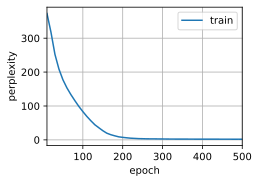

In [43]:
num_epochs, lr = 500, 1
device = d2l.try_gpu()
net = net.to(device)
train_ch8(net, train_iter, vocab, lr, num_epochs, device)

In [45]:
predict2 = lambda prefix: predict_ch8(prefix, 500, net, vocab, device)
predict2('hello world')

['h', 'ell', 'o</w>', 'world</w>']


"hello world man had been a dream . ' and yet , not exactly ! the thing had started from the south - east corner of the laboratory . it had come to rest again in the north - west , against the wall where you saw it . that gives you the exact distance from my little lawn to the pedestal of the white sphinx , into which the morlocks had carried my machine . ' for a time my brain went stagnant . presently i got up and came through the passage here , limping , because my heel was still painful , and feeling sorely begrimed . i saw the _ pall mall gazette _ on the table by the door . i found the date was indeed to - day , and looking at the timepiece , saw the hour was almost eight o ' clock . i heard your voices and the clatter of plates . i hesitated - - i felt so sick and weak . then i sniffed good wholesome meat , and opened the door on you . you know the rest . i washed , and dined , and now i am telling you the story . ' i know , ' he said , after a pause , ' that all this will be abs